In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import math

from numba import cuda

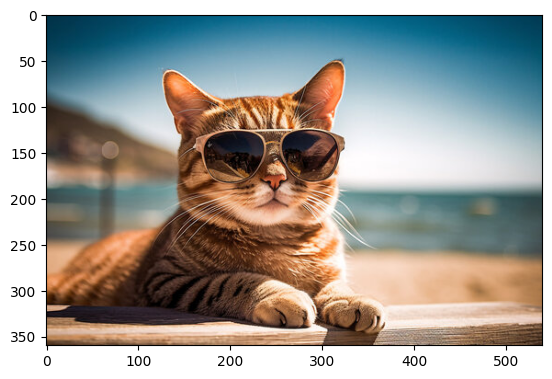

In [3]:
img = plt.imread('cat.jpg')

plt.imshow(img)

In [4]:
height, width = img.shape[:2]
gridSize = (8,8)
blockSize = (32,32)

In [5]:
@cuda.jit
def grayscale(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  g = np.uint8((src[tidy, tidx, 0] + src[tidy, tidx, 1] + src[tidy, tidx, 2]) / 3)
  dst[tidy, tidx, 0] = dst[tidy, tidx, 1] = dst[tidy, tidx, 2] = g

In [6]:
start = time.time()

devSrc = cuda.to_device(img)
devDst = cuda.device_array(img.shape, np.uint8)
grayscale[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()
hostDst = devDst.copy_to_host()

gpuTime = time.time() - start
print("GPU time: ", gpuTime)

/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


GPU time:  4.275647163391113


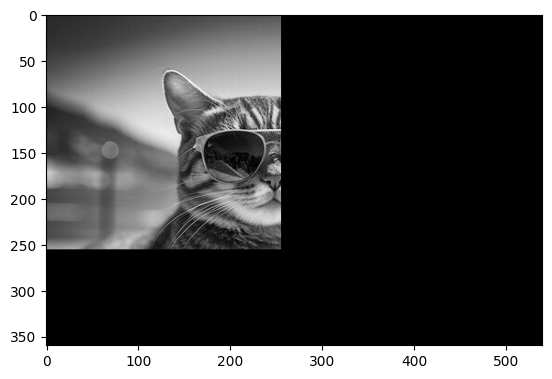

In [7]:
plt.imshow(hostDst)

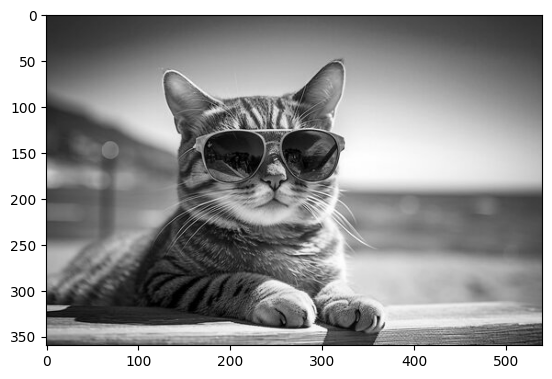

In [8]:
blockSize = (32, 32)
gridSize = (math.ceil(width / blockSize[0]), math.ceil(height / blockSize[1]))
devSrc = cuda.to_device(img)
devDst = cuda.device_array(img.shape, np.uint8)
grayscale[gridSize, blockSize](devSrc, devDst)
hostDst = devDst.copy_to_host()
plt.imshow(hostDst)

In [30]:
blocks = [(8, 8), (8, 16), (16, 16), (16, 32)]
times = []

for blockSize in blocks:
    gridSize = (math.ceil(width / blockSize[0]), math.ceil(height / blockSize[1]))

    start = time.time()

    devSrc = cuda.to_device(img)
    devDst = cuda.device_array(img.shape, np.uint8)
    grayscale[gridSize, blockSize](devSrc, devDst)

    elapsed = time.time() - start
    times.append(elapsed)

    hostDst = devDst.copy_to_host()

    print(
        "Block:", blockSize,
        "Grid:", gridSize,
        "Time:", elapsed
    )

Block: (8, 8) Grid: (68, 45) Time: 0.001621246337890625
Block: (8, 16) Grid: (68, 23) Time: 0.001332998275756836
Block: (16, 16) Grid: (34, 23) Time: 0.0009386539459228516
Block: (16, 32) Grid: (34, 12) Time: 0.0009980201721191406


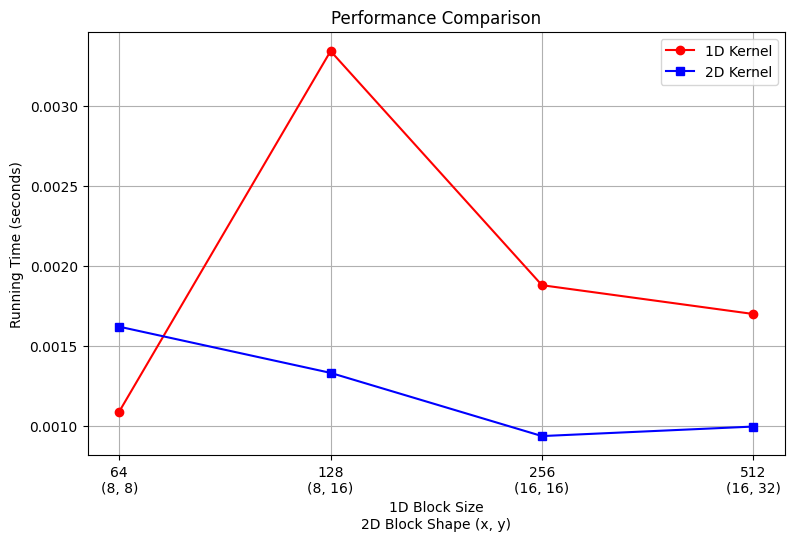

In [35]:
import matplotlib.pyplot as plt

r1d = {
    64: 0.0010914802551269531,
    128: 0.003341197967529297,
    256: 0.0018801689147949219,
    512: 0.0017004013061523438
}

x_labels = [
    "64\n(8, 8)",
    "128\n(8, 16)",
    "256\n(16, 16)",
    "512\n(16, 32)"
]
x_indices = range(len(x_labels))

y_1d = list(r1d.values())
y_2d = times

plt.figure(figsize=(9, 5.5))
plt.plot(x_indices, y_1d, marker='o', label='1D Kernel', color='r')
plt.plot(x_indices, y_2d, marker='s', label='2D Kernel', color='b')

plt.xticks(x_indices, x_labels)
plt.xlabel("1D Block Size\n2D Block Shape (x, y)")
plt.ylabel("Running Time (seconds)")
plt.title("Performance Comparison")

plt.legend()
plt.grid(True)
plt.show()